# Funciones básicas para armar ST-DIP

Author: Evelyn Cueva
Created: 2023-09-02


## MapNet con Flax NNX

Mapnet is a fully connected neural network with relu activations. It takes as input coordinate (2D or 3D) and outputs a feature vector of a specified dimension.

In [2]:
from typing import Sequence
import jax
import jax.numpy as jnp
from flax import nnx

class MapNetNNX(nnx.Module):
    """
    Mapping network implementado en Flax NNX.

    Construye una red feed-forward con varias capas ocultas `Linear` seguidas de
    funciones de activación ReLU, y una capa de salida lineal.

    Parameters
    ----------
    in_features : int
        Número de características de entrada (dimensión de la primera capa).
        Por ejemplo, 3 si se pasa un vector (x, y, z).
    hidden_sizes : Sequence[int]
        Lista con el número de neuronas en cada capa oculta.
        Ejemplo: (8, 8) crea dos capas ocultas de 8 unidades cada una.
    out_features : int
        Número de neuronas de la capa de salida. Por ejemplo, 64 si se requiere
        un vector latente de tamaño 64.
    rngs : nnx.Rngs
        Generador de números aleatorios de NNX para inicializar los parámetros.

    Example
    -------
    >>> rngs = nnx.Rngs(0)
    >>> model = MapNetNNX(in_features=3, hidden_sizes=(8, 8), out_features=64, rngs=rngs)
    >>> x = jnp.ones((1, 3))     # batch=1, input=(x,y,z)
    >>> y = model(x)             # salida de shape (1, 64)
    >>> y.shape
    (1, 64)
    """

    def __init__(self,
                 in_features: int,
                 hidden_sizes: Sequence[int],
                 out_features: int,
                 rngs: nnx.Rngs):
        # Construcción de las capas ocultas
        self.hidden: list[nnx.Linear] = []
        prev = in_features
        for i, h in enumerate(hidden_sizes):
            # Capa densa oculta de tamaño h
            self.hidden.append(nnx.Linear(prev, h, rngs=rngs))
            prev = h

        # Capa de salida que proyecta a out_features
        self.out = nnx.Linear(prev, out_features, rngs=rngs)

    def __call__(self, x: jax.Array) -> jax.Array:
        """
        Ejecuta el forward pass de la red.

        Parameters
        ----------
        x : jax.Array
            Entrada de forma (batch, in_features) o (..., in_features).

        Returns
        -------
        jax.Array
            Salida de forma (..., out_features).
        """
        # Pasar por cada capa oculta + ReLU
        for layer in self.hidden:
            x = layer(x)
            x = jax.nn.relu(x)

        # Proyección final sin activación
        x = self.out(x)
        return x


### Ejemplo de uso de MapNetNNX

El siguiente ejemplo recibe un valor $x$ y entrena MapNetNNX para aproximar la función $y = sin(x).$ 

In [ ]:
import optax

# === Datos sintéticos: y = sin(x) con algo de ruido ===
key = jax.random.key(0)
x_train = jax.random.uniform(key, (1024, 1), minval=-jnp.pi, maxval=jnp.pi)
y_train = jnp.sin(x_train) + 0.05 * jax.random.normal(jax.random.split(key)[0], x_train.shape)

# === Modelo y optimizador ===
rngs = nnx.Rngs(42)
model = MapNetNNX(in_features=1, hidden_sizes=(64, 64), out_features=1, rngs=rngs)
optimizer = nnx.Optimizer(model, optax.adam(1e-3), wrt=nnx.Param)

# === Función de pérdida ===
def loss_fn(model, xb, yb):
    preds = model(xb) # ocupa la definicion de _call_ del modelo
    return jnp.mean((preds - yb) ** 2)

# === Un paso de entrenamiento ===
def train_step(model, optimizer, xb, yb):
    def _loss(m): # generico, es para la derivacion automática
        return loss_fn(m, xb, yb) #solo depende del modelo, datos de entrenamiento y datos verdaderos
    loss, grads = nnx.value_and_grad(_loss)(model) #calculo de gradientes nada que ver con el optimizador
    optimizer.update(model, grads)  # actualiza los parámetros del modelo in-place con el paso del metodo de descenso (optimizer).
    return loss

# === Loop de entrenamiento simple ===
batch_size = 128
n_steps = 2000

for step in range(1, n_steps + 1):
    # muestreo mini-batch
    k1, key = jax.random.split(key)
    idx = jax.random.choice(k1, x_train.shape[0], (batch_size,), replace=False)
    xb, yb = x_train[idx], y_train[idx]

    l = train_step(model, optimizer, xb, yb)

    if step % 200 == 0:
        print(f"step {step:4d} | loss {float(l):.6f}")

# === Prueba rápida ===
x_test = jnp.linspace(-jnp.pi, jnp.pi, 200).reshape(-1, 1)
y_pred = model(x_test)
print("Pred sample:", y_pred[:5].flatten())

step  200 | loss 0.023537
step  400 | loss 0.004284
step  600 | loss 0.003022
step  800 | loss 0.002937
step 1000 | loss 0.002413
step 1200 | loss 0.002712
step 1400 | loss 0.003301
step 1600 | loss 0.002392
step 1800 | loss 0.002202
step 2000 | loss 0.004112
Pred sample: [-0.0099616  -0.0394522  -0.06894397 -0.09843505 -0.12792608]


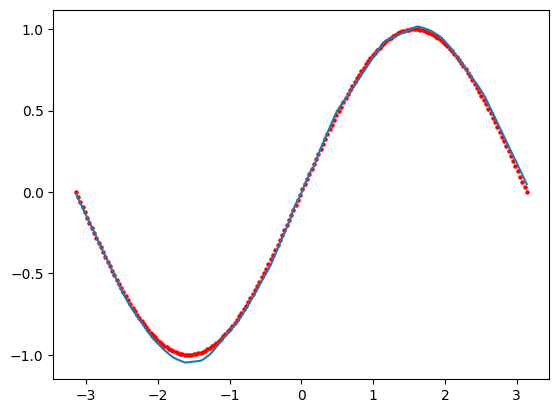

In [ ]:
import matplotlib.pyplot as plt

plt.plot(x_test, y_pred, label='Predicción')
plt.scatter(x_test, jnp.sin(x_test), color='r', s=5, label='Verdadero')

## Decoder Net

In [11]:
from typing import List, Optional, Tuple
import jax, jax.numpy as jnp
from flax import nnx

# ---------- util ----------
def upsample_2d(x: jax.Array, scale: int = 2, method: str = "nearest") -> jax.Array:
    if scale == 1:
        return x
    # NHWC, nearest
    x = jnp.repeat(x, scale, axis=1)
    x = jnp.repeat(x, scale, axis=2)
    return x

# ---------- bloques ----------
class ConvBNReLU(nnx.Module):
    def __init__(
        self,
        in_channels: int,
        out_channels: int,
        kernel_size: Tuple[int,int]=(3,3),
        strides: Tuple[int,int]=(1,1),
        momentum: float = 0.99,
        rngs: Optional[nnx.Rngs] = None,
    ):
        self.conv = nnx.Conv(
            in_channels, out_channels,
            kernel_size=kernel_size,
            strides=strides,
            padding="SAME",
            rngs=rngs,
        )
        self.bn = nnx.BatchNorm(
            num_features=out_channels,
            momentum=momentum,
            epsilon=1e-5,
            axis=-1, 
            rngs=rngs,
        )

    def __call__(self, x: jax.Array, training: bool) -> jax.Array:
        x = self.conv(x)
        x = self.bn(x, use_running_average=not training)
        return jax.nn.relu(x)

class DecoderNNX(nnx.Module):
    """
    Decoder 2D NHWC sin lazy-build.
    Estructura: 2x(ConvBNReLU) -> Upsample -> [levels * (2x(ConvBNReLU) -> Upsample)] -> 2x(ConvBNReLU) -> Conv final
    """
    def __init__(
        self,
        in_channels: int,            # 1 si tu MapNet->reshape añade un solo canal
        features: int = 128,
        momentum: float = 0.99,
        levels: int = 3,
        out_features: int = 2,
        upsampling_method: str = "nearest",
        upsampling_factor: int = 2,
        rngs: Optional[nnx.Rngs] = None,
    ):
        self.features = features
        self.levels = levels
        self.out_features = out_features
        self.upsampling_method = upsampling_method
        self.upsampling_factor = upsampling_factor
        self.rngs = rngs if rngs is not None else nnx.Rngs(0)

        # Head
        self.head: List[ConvBNReLU] = [
            ConvBNReLU(in_channels, features, momentum=momentum, rngs=self.rngs),
            ConvBNReLU(features,    features, momentum=momentum, rngs=self.rngs),
        ]

        # Body
        self.body: List[List[ConvBNReLU]] = []
        for _ in range(levels):
            self.body.append([
                ConvBNReLU(features, features, momentum=momentum, rngs=self.rngs),
                ConvBNReLU(features, features, momentum=momentum, rngs=self.rngs),
            ])

        # Tail
        self.tail: List[ConvBNReLU] = [
            ConvBNReLU(features, features, momentum=momentum, rngs=self.rngs),
            ConvBNReLU(features, features, momentum=momentum, rngs=self.rngs),
        ]

        # Conv final
        self.final_conv = nnx.Conv(
            features, out_features,
            kernel_size=(3,3),
            strides=(1,1),
            padding="SAME",
            rngs=self.rngs,
        )

    def __call__(self, x: jax.Array, training: bool) -> jax.Array:
        for blk in self.head:
            x = blk(x, training=training)

        x = upsample_2d(x, scale=self.upsampling_factor, method=self.upsampling_method)

        for level_blocks in self.body:
            for blk in level_blocks:
                x = blk(x, training=training)
            x = upsample_2d(x, scale=self.upsampling_factor, method=self.upsampling_method)

        for blk in self.tail:
            x = blk(x, training=training)

        return self.final_conv(x)

### Ejemplo con DecoderNetNNX

In [ ]:
# --------- objetivo sintético suave 128x128x2 ---------
def make_target(H=128, W=128):
    ys = jnp.linspace(-1, 1, H)
    xs = jnp.linspace(-1, 1, W)
    Y, X = jnp.meshgrid(ys, xs, indexing="ij")
    R = jnp.sqrt(X**2 + Y**2)

    # Canal 0: disco gaussiano
    sigma = 0.35
    ch0 = jnp.exp(- (R**2) / (2 * sigma**2))

    # Canal 1: patrón sinusoidal suave
    ch1 = 0.5 * (jnp.sin(3*jnp.pi*X) * jnp.sin(3*jnp.pi*Y)) + 0.5

    target = jnp.stack([ch0, ch1], axis=-1)  # (H, W, 2)
    target = target[None, ...]               # (1, H, W, 2) para NHWC con batch=1
    return target

# --------- setup experimento DIP-like ---------
key = jax.random.key(0)

levels = 3
up = 2
scale_total = up ** (1 + levels)  # 2^(1+3) = 16
H_out = 128
W_out = 128
H_in = H_out // scale_total       # 8
W_in = W_out // scale_total       # 8

assert H_out % scale_total == 0 and W_out % scale_total == 0, "Ajusta niveles o upsampling_factor."

# Entrada (ruido fijo) y objetivo
z = jax.random.normal(key, (1, H_in, W_in, 1))  # NHWC
y_true = make_target(H_out, W_out)              # (1, 128, 128, 2)

# Modelo y optimizador (NNX >= 0.11)
rngs = nnx.Rngs(42)
model = DecoderNNX(in_channels=1, features=64, levels=levels,
                   out_features=2, upsampling_factor=up, rngs=rngs)
optimizer = nnx.Optimizer(model, optax.adam(1e-3), wrt=nnx.Param)

# Pérdida MSE simple
def loss_fn(m: DecoderNNX, z: jax.Array, y: jax.Array):
    yhat = m(z, training=True)
    return jnp.mean((yhat - y) ** 2)

# Un paso de entrenamiento (API nueva: update(model, grads))
def train_step(m: DecoderNNX, opt: nnx.Optimizer, z: jax.Array, y: jax.Array):
    def _loss(m_):
        return loss_fn(m_, z, y)
    loss, grads = nnx.value_and_grad(_loss)(m)
    opt.update(m, grads)
    return loss

# Loop simple
# Sin batch, todo el objetivo a la vez
n_steps = 1500
for step in range(1, n_steps + 1):
    l = train_step(model, optimizer, z, y_true)
    if step % 150 == 0:
        print(f"step {step:4d} | loss {float(l):.6f}")

# Evaluación (usar promedios corridos en BN)
y_pred = model(z, training=False)
print("Output shape:", y_pred.shape, "| min/max:", float(y_pred.min()), float(y_pred.max()))

step  150 | loss 0.000262
step  300 | loss 0.000118
step  450 | loss 0.000075
step  600 | loss 0.000054
step  750 | loss 0.000041
step  900 | loss 0.000033
step 1050 | loss 0.000030
step 1200 | loss 0.000023
step 1350 | loss 0.000019
step 1500 | loss 0.000017
Output shape: (1, 128, 128, 2) | min/max: -0.05810176953673363 1.0155140161514282


(-0.5, 127.5, 127.5, -0.5)

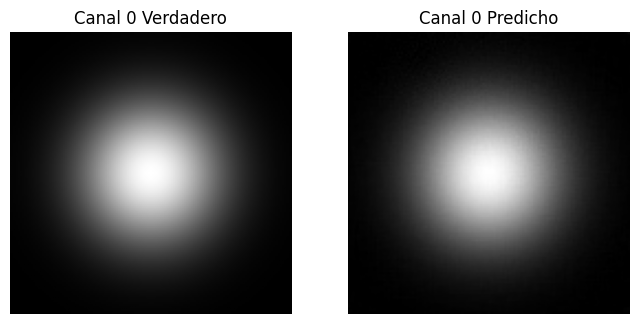

In [22]:
plt.figure(figsize=(8,4))
plt.subplot(1,2,1)
plt.imshow(jnp.abs(y_true[0,:,:,0]), cmap='gray')
plt.title("Canal 0 Verdadero")
plt.axis('off')
plt.subplot(1,2,2)
plt.imshow(jnp.abs(y_pred[0,:,:,0]), cmap='gray')
plt.title("Canal 0 Predicho")
plt.axis('off')

## Unión de MapNeet + Decoder

In [23]:
from typing import Sequence, Tuple, Optional
import jax
import jax.numpy as jnp
from flax import nnx

class TDIPNNX(nnx.Module):
    """
    tDIP en NNX: MapNet -> reshape (px, py) -> añadir canal -> Decoder.

    map_in_features: dimensión de t
    map_hidden_sizes: capas de MapNet
    cnn_latent_shape: (px, py) que produce MapNet (antes de añadir canal)
    decoder_features: # filtros internos del decoder
    momentum: BN momentum dentro del decoder
    levels: # de niveles [2xConvBNReLU -> upsample] del decoder
    out_features: canales de salida
    upsampling_method: 'nearest' o 'bilinear'
    upsampling_factor: factor de upsample por nivel
    rngs: RNGs compartidos
    """
    def __init__(
        self,
        map_in_features: int,
        map_hidden_sizes: Sequence[int],
        cnn_latent_shape: Tuple[int, int],
        decoder_features: int,
        momentum: float,
        levels: int,
        out_features: int = 2,
        upsampling_method: str = "nearest",
        upsampling_factor: int = 2,
        rngs: Optional[nnx.Rngs] = None,
    ):
        self.px, self.py = cnn_latent_shape
        self.rngs = rngs if rngs is not None else nnx.Rngs(0)

        # 1) MapNet: (N, map_in_features) -> (N, px*py)
        self.mapnet = MapNetNNX(
            in_features=map_in_features,
            hidden_sizes=map_hidden_sizes,
            out_features=self.px * self.py,
            rngs=self.rngs,
        )

        # 2) Decoder: entrada NHWC con C=1 (después del reshape)
        self.decoder = DecoderNNX(
            in_channels=1,                  
            features=decoder_features,
            momentum=momentum,
            levels=levels,
            out_features=out_features,
            upsampling_method=upsampling_method,
            upsampling_factor=upsampling_factor,
            rngs=self.rngs,
        )

    def __call__(self, t: jax.Array, training: bool) -> jax.Array:
        """
        t: (N, map_in_features)  ->  y: (N, H_out, W_out, out_features)
        """
        # MapNet
        x = self.mapnet(t)                               # (N, px*py)

        # Reshape + canal
        x = jnp.reshape(x, (x.shape[0], self.px, self.py, 1))  # (N, px, py, 1)

        # Decoder
        y = self.decoder(x, training=training)           # (N, H_out, W_out, out_features)
        return y


### Ejemplo con MapNetNNX + DecoderNNX

In [26]:
# ====== dataset dinámico sintético ======
def make_dyn_target_batch(t_vals: jax.Array, H: int, W: int) -> jax.Array:
    """
    t_vals: (N, 1) en [0,1]
    return: (N, H, W, 2)
    """
    ys = jnp.linspace(-1, 1, H)
    xs = jnp.linspace(-1, 1, W)
    Y, X = jnp.meshgrid(ys, xs, indexing="ij")

    def frame_at_t(t):
        theta = 2 * jnp.pi * t
        cx, cy = 0.3 * jnp.cos(theta), 0.3 * jnp.sin(theta)
        sigma = 0.25
        ch0 = jnp.exp(-((X - cx)**2 + (Y - cy)**2) / (2 * sigma**2))
        # patrón sinusoidal que rota con t
        kx, ky = 3.0, 3.0
        ch1 = 0.5 * (jnp.sin(kx*(X*jnp.cos(theta) - Y*jnp.sin(theta)) + 2*jnp.pi*t) *
                     jnp.sin(ky*(X*jnp.sin(theta) + Y*jnp.cos(theta)) + 2*jnp.pi*t)) + 0.5
        return jnp.stack([ch0, ch1], axis=-1)  # (H, W, 2)

    # vmap sobre la primera dimensión de t_vals
    return jax.vmap(lambda tau: frame_at_t(tau[0]))(t_vals)  # (N, H, W, 2)

# ====== configuración del experimento ======
key = jax.random.key(0)

# Dimensiones
levels = 3
up = 2
scale_total = up ** (1 + levels)  # 2^(1+3)=16
px, py = 8, 8                      # tamaño del "latente imagen" que produce MapNet
H_out, W_out = px * scale_total, py * scale_total  # 128x128
assert H_out == 128 and W_out == 128

# Secuencia temporal
N = 31
t_vals = jnp.linspace(0.0, 1.0, N).reshape(N, 1)   # (N, map_in_features=1)
y_true = make_dyn_target_batch(t_vals, H_out, W_out)  # (N, 128, 128, 2)

# ====== modelo + optimizador (NNX >= 0.11) ======
rngs = nnx.Rngs(42)
model = TDIPNNX(
    map_in_features=1,
    map_hidden_sizes=(64, 64),
    cnn_latent_shape=(px, py),
    decoder_features=64,
    momentum=0.9,
    levels=levels,
    out_features=2,              # 2 canales (p.ej., real/imag)
    upsampling_method="nearest",
    upsampling_factor=up,
    rngs=rngs,
)

optimizer = nnx.Optimizer(model, optax.adam(1e-3), wrt=nnx.Param)

# ====== pérdida y paso de entrenamiento ======
def loss_fn(m: TDIPNNX, t_batch: jax.Array, y_batch: jax.Array):
    yhat = m(t_batch, training=True)
    return jnp.mean((yhat - y_batch) ** 2)

def train_step(m: TDIPNNX, opt: nnx.Optimizer, t_batch: jax.Array, y_batch: jax.Array):
    def _loss(m_):
        return loss_fn(m_, t_batch, y_batch)
    loss, grads = nnx.value_and_grad(_loss)(m)
    opt.update(m, grads)  # API nueva: (model, grads)
    return loss

# ====== loop (full-batch para simplificar) ======
n_steps = 1500
for step in range(1, n_steps + 1):
    l = train_step(model, optimizer, t_vals, y_true)
    if step % 150 == 0:
        print(f"step {step:4d} | loss {float(l):.6f}")

# ====== evaluación (BN en modo inferencia) ======
y_pred = model(t_vals, training=False)
print("y_pred shape:", y_pred.shape, " | min/max:", float(y_pred.min()), float(y_pred.max()))


step  150 | loss 0.006846
step  300 | loss 0.002526
step  450 | loss 0.001324
step  600 | loss 0.000821
step  750 | loss 0.000817
step  900 | loss 0.000455
step 1050 | loss 0.000428
step 1200 | loss 0.000416
step 1350 | loss 0.000359
step 1500 | loss 0.000277
y_pred shape: (31, 128, 128, 2)  | min/max: -0.10085667669773102 1.0481743812561035


#### Visuallización de resultados

In [30]:
# ===== Video helpers para (N, H, W, C) =====
from typing import Literal, Optional
import numpy as np
import imageio.v3 as iio

def prepare_frames_uint8(
    frames: np.ndarray,
    visualization: Literal["magnitude", "channel"] = "magnitude",
    channel: int = 0,
    normalize: Literal["global", "per_frame"] = "global",
) -> np.ndarray:
    """
    Convierte frames (N,H,W,C) -> (N,H,W) uint8 para video.
    - visualization="magnitude": usa sqrt(ch0^2 + ch1^2) (requiere C>=2).
    - visualization="channel": usa un canal específico (channel=0/1/...).
    - normalize="global": mismo contraste para todo el video.
      "per_frame": normaliza cada frame (útil si varía mucho la intensidad).
    """
    arr = np.asarray(frames)  # por si viene como jax.Array
    if arr.ndim == 3:  # (N,H,W) sin canales
        gray = arr
    else:
        assert arr.ndim == 4, f"Se esperaba (N,H,W,C), obtuve {arr.shape}"
        if visualization == "magnitude":
            assert arr.shape[-1] >= 2, "Se requieren >=2 canales para magnitud."
            gray = np.sqrt(arr[..., 0]**2 + arr[..., 1]**2)
        else:  # "channel"
            gray = arr[..., channel]

    if normalize == "global":
        vmin, vmax = float(gray.min()), float(gray.max())
        if vmax <= vmin:
            gray_u8 = np.zeros_like(gray, dtype=np.uint8)
        else:
            gray_u8 = ((gray - vmin) / (vmax - vmin) * 255.0).clip(0, 255).astype(np.uint8)
    else:  # "per_frame"
        N = gray.shape[0]
        gray_u8 = np.empty_like(gray, dtype=np.uint8)
        for i in range(N):
            g = gray[i]
            vmin, vmax = float(g.min()), float(g.max())
            if vmax <= vmin:
                gray_u8[i] = np.zeros_like(g, dtype=np.uint8)
            else:
                gray_u8[i] = ((g - vmin) / (vmax - vmin) * 255.0).clip(0, 255).astype(np.uint8)

    return gray_u8  # (N,H,W), uint8


def save_gif(frames_u8: np.ndarray, path: str = "video.gif", fps: int = 15):
    """
    Guarda GIF animado con imageio (no requiere ffmpeg).
    """
    assert frames_u8.ndim == 3, "Se espera (N,H,W) uint8"
    duration = 1.0 / fps  # seg por frame
    iio.imwrite(path, frames_u8, extension=".gif", duration=duration, loop=0)
    print(f"GIF guardado en: {path}")


def save_mp4(frames_u8: np.ndarray, path: str = "video.mp4", fps: int = 15):
    """
    Guarda MP4 (requiere que imageio encuentre ffmpeg; suele bastar con `pip install imageio-ffmpeg`).
    """
    assert frames_u8.ndim == 3, "Se espera (N,H,W) uint8"
    # Convertir a (N,H,W,3) para video coloreado (grayscale replicado)
    rgb = np.stack([frames_u8]*3, axis=-1)
    iio.imwrite(path, rgb)
    print(f"MP4 guardado en: {path}")


In [ ]:
# y_pred: (N, H, W, 2)  # p. ej., salida de tu TDIPNNX (2 canales = re/imag)
frames_u8 = prepare_frames_uint8(y_pred, visualization="magnitude", normalize="global")

# GIF (no requiere ffmpeg)
save_gif(frames_u8, "tdip.gif")

# MP4 (mejor calidad/sin peso; requiere ffmpeg disponible)
# pip install imageio-ffmpeg  # si hace falta
save_mp4(frames_u8, "tdip.mp4")

GIF guardado en: tdip.gif
MP4 guardado en: tdip.mp4


In [32]:
frames_u8_true = prepare_frames_uint8(y_true, visualization="magnitude", normalize="global")
save_gif(frames_u8_true, "tdip_true.gif")
save_mp4(frames_u8_true, "tdip_true.mp4")

GIF guardado en: tdip_true.gif
MP4 guardado en: tdip_true.mp4


# Lo veo más adelante

In [ ]:
from typing import Sequence, Tuple, Optional, Union
import jax
import jax.numpy as jnp
from flax import nnx

# ----------------------------------------------------------------------
# Utilidad: juntar canales (real, imag) -> complejo
# y recortar a imshape final.
# ----------------------------------------------------------------------
def _to_complex_and_crop(y: jax.Array, imshape: Tuple[int, int], out_images: int) -> jax.Array:
    """
    y: (B, H, W, 2*out_images)  ->  (B, nx, ny, out_images) complejo
    """
    nx, ny = imshape
    y = y[:, :nx, :ny, :]
    real = y[..., :out_images]
    imag = y[..., out_images:2*out_images]
    y_c = real + 1j * imag
    return y_c

# ----------------------------------------------------------------------
# Wrapper NNX para tDIP dependiente de tiempo
# ----------------------------------------------------------------------
class TimeDependant_DIP_Net_NNX:
    """
    Implementación NNX del wrapper de Time-Dependent DIP.

    - Genera latentes por frame con `latent_generator`.
    - Contiene un `TDIPNNX` (MapNet + Decoder) que consume vectores latentes.
    - Expone métodos para warm-up, split/graphdef, y forward de entrenamiento/evaluación.

    Parameters
    ----------
    nframes : int
        Número de frames.
    total_cycles : int
        Parámetro de la trayectoria temporal del generador de latentes.
    latent_generator : Callable
        Debe devolver array (nframes, map_in_features).
    imshape : (int, int)
        Tamaño espacial final (nx, ny).
    mapnet_layers : Sequence[int]
        Capas ocultas de MapNet.
    cnn_latent_shape : (int, int)
        Grilla latente para el decoder.
    features : int
        Canales intermedios del decoder.
    momentum : float
        Momentum de BatchNorm.
    levels : int
        Niveles del decoder.
    out_images : int
        Cantidad de imágenes de salida (cada una con real+imag).
    rngs : nnx.Rngs | None
        RNGs para inicialización.
    """

    def __init__(self,
                 nframes: int,
                 total_cycles: int,
                 latent_generator,
                 imshape: Tuple[int, int],
                 mapnet_layers: Sequence[int],
                 cnn_latent_shape: Tuple[int, int] = (8, 8),
                 features: int = 128,
                 momentum: float = 0.99,
                 levels: int = 3,
                 out_images: int = 1,
                 rngs: Optional[nnx.Rngs] = None):

        self.nframes = int(nframes)
        self.total_cycles = int(total_cycles)
        self.imshape = tuple(imshape)
        self.out_images = int(out_images)

        # Latentes (nframes, map_in_features)
        latent_np = latent_generator(self.nframes, self.total_cycles)
        self.latent = jnp.asarray(latent_np)
        self.map_in_features = int(self.latent.shape[-1])

        # Modelo NNX
        self.rngs = rngs if rngs is not None else nnx.Rngs(0)
        self.net = TDIPNNX(
            map_in_features=self.map_in_features,
            map_hidden_sizes=mapnet_layers,
            cnn_latent_shape=cnn_latent_shape,
            decoder_features=features,
            momentum=momentum,
            levels=levels,
            out_features=2 * self.out_images,  # real+imag por salida
            rngs=self.rngs,
        )

        # Se llenará después del warm-up
        self.params = None
        self.state = None
        self.graphdef = None

    # ------------------------------------------------------------------
    # Warm-up + split + graphdef (para evitar mismatch de leaves)
    # ------------------------------------------------------------------
    def initialize(self, key: jax.Array) -> Tuple[dict, dict]:
        """
        Hace un forward mínimo para materializar estados, luego split y graphdef.

        Returns
        -------
        (params, state)
        """
        # Forward mínimo (B=1) para construir estados perezosos (e.g. BN)
        t0 = self.latent[0:1, :]  # (1, map_in_features)
        _ = self.net(t0, training=True)  # sin nnx.update; solo materializa shapes/vars

        # Ahora sí, separar variables y capturar graphdef consistente
        self.params, self.state = nnx.split(self.net)
        self.graphdef = nnx.graphdef(self.net)
        return self.params, self.state

    # ------------------------------------------------------------------
    # Acceso a latentes (índice o lote de índices)
    # ------------------------------------------------------------------
    def get_latent(self, t_index: Optional[Union[int, jax.Array]] = None) -> jax.Array:
        """
        t_index: int o array de enteros. Si None, devuelve todos los latentes.
        """
        if t_index is None:
            return self.latent
        return self.latent[t_index, :]  # soporta int o (B,)

    # ------------------------------------------------------------------
    # Forward de entrenamiento (funcional): usa params/state externos
    # ------------------------------------------------------------------
    def train_forward_pass(self,
                           params: dict,
                           state: dict,
                           key: jax.Array,
                           t_index: Union[int, jax.Array]) -> Tuple[jax.Array, dict]:
        """
        Devuelve (y_complex, new_state)
          - y_complex: (B, nx, ny, out_images) complejo
          - new_state: PyTree con estados actualizados (e.g., batch_stats)
        """
        if self.graphdef is None:
            raise RuntimeError("Llama primero a initialize(key) para construir graphdef/vars.")

        t = self.get_latent(t_index)              # (B, F) o (F,)
        if t.ndim == 1:
            t = t[None, :]                        # (1, F)

        # Reconstruir instancia viva
        net_live = nnx.merge(self.graphdef, params, state, copy=True)

        # Forward de entrenamiento (sin nnx.update para compatibilidad)
        y = net_live(t, training=True)

        new_state = nnx.state(net_live)  # recoge estado actualizado
        y_c = _to_complex_and_crop(y, self.imshape, self.out_images)
        return y_c, new_state
    # ------------------------------------------------------------------
    # Forward de evaluación (sin mutar estado)
    # ------------------------------------------------------------------
    def eval_forward_pass(self,
                          params: dict,
                          state: dict,
                          key: jax.Array,
                          t_index: Union[int, jax.Array]) -> jax.Array:
        """
        Devuelve y_complex: (B, nx, ny, out_images) complejo. No muta estado.
        """
        if self.graphdef is None:
            raise RuntimeError("Llama primero a initialize(key) para construir graphdef/vars.")

        t = self.get_latent(t_index)
        if t.ndim == 1:
            t = t[None, :]

        net_live = nnx.merge(self.graphdef, params, state, copy=True)
        y = net_live(t, training=False)
        y_c = _to_complex_and_crop(y, self.imshape, self.out_images)
        return y_c


#### Ejemplo sintético para practicar un entrenamiento

In [ ]:
NFRAMES = 10
TOTAL_CYCLES = 1
N = 128  # tamaño imagen final
mapnet_layers = (8, 8)  # capas ocultas de MapNet
cnn_latent_shape = (8, 8)  # grilla latente para el
features = 128  # canales intermedios del decoder
momentum = 0.99  # momentum de BatchNorm
levels = 3  # niveles del decoder
key_step = jax.random.PRNGKey(0)
times = jnp.linspace(0, 1, NFRAMES, endpoint=False)  # ejemplo de tiempos normalizados [0,1)
t_idx = (times * NFRAMES).astype(jnp.int32)

def helix_generator(nframes, total_cycles):
    ts = jnp.linspace(0,total_cycles, nframes, endpoint=False)
    helix = jnp.stack([jnp.cos(ts*2*jnp.pi), jnp.sin(ts*2*jnp.pi), ts/total_cycles], axis=-1)
    return helix


# 1) Crear wrapper NNX
tdip = TimeDependant_DIP_Net_NNX(
    nframes=NFRAMES,
    total_cycles=TOTAL_CYCLES,
    latent_generator=helix_generator,   # -> (nframes, map_in_features)
    imshape=(N, N),
    mapnet_layers=mapnet_layers,
    cnn_latent_shape=cnn_latent_shape,
    features=features,
    momentum=momentum,
    levels=levels,
    out_images=1,
    rngs=nnx.Rngs(0),
)

# 2) Warm-up + split + graphdef
params, state = tdip.initialize(jax.random.key(0))

# 2) (opcional) verifica coherencia
def _num_leaves(x): return len(jax.tree_util.tree_flatten(x)[0])
print("graphdef.num_leaves:", tdip.graphdef.num_leaves)
print("params+state leaves:", _num_leaves(params) + _num_leaves(state))

# 3) En tu loss (o paso de entrenamiento):
#    si ya computes t_idx = (times * NFRAMES).astype(jnp.int32)
y_c, new_state = tdip.train_forward_pass(params, state, key_step, t_idx)
# y_c: (B, nx, ny, out_images) complejo


graphdef.num_leaves: 70
params+state leaves: 70


ValueError: Incorrect number of leaves, expected 70 leaves, but got 71.

In [ ]:
times.shape

(10,)

In [ ]:
import jax
import jax.numpy as jnp
import optax
from flax import nnx
from typing import Tuple

# --------- utilidades FFT (single-coil) ----------
def fft2c(x):   # x: (N,H,W) complejo
    return jnp.fft.fft2(x, norm='ortho')

def ifft2c(k):
    return jnp.fft.ifft2(k, norm='ortho')

# --------- manifold Z: p ciclos sobre el círculo ----------
def make_temporal_coords(K: int, p: int, d: int = 2):
    """
    Coordenadas en una circunferencia con p ciclos a lo largo de K frames.
    Devuelve t: (K, d). Para d>2, rellena con ceros.
    """
    # ángulo por frame mapeado a p ciclos
    ang = 2.0 * jnp.pi * (jnp.arange(K) / K) * p
    base = jnp.stack([jnp.cos(ang), jnp.sin(ang)], axis=-1)  # (K,2)
    if d == 2:
        return base
    if d > 2:
        pad = jnp.zeros((K, d-2))
        return jnp.concatenate([base, pad], axis=-1)
    raise ValueError("d debe ser >= 2")

# --------- data fidelity (single-coil) ----------
def forward_singlecoil(img_batch, mask_batch):
    """
    img_batch: (B,H,W) complejo   (salida del decoder convertida a complejo)
    mask_batch: (B,H,W) {0,1}
    """
    kpred = fft2c(img_batch)
    return kpred * mask_batch

def mse(a, b):
    return jnp.mean(jnp.abs(a - b) ** 2)

# --------- Pérdida por batch ----------
def batch_loss(model, t_batch, y_batch, mask_batch, training: bool):
    """
    model: TDIPNNX
    t_batch: (B, d)
    y_batch: (B,H,W) complejo en k-espacio
    mask_batch: (B,H,W) binario
    """
    # 1) modelo produce 2 canales (Re, Im) en imagen
    x_hat_ri = model(t_batch, training=training)     # (B,H,W,2)
    x_hat = x_hat_ri[..., 0] + 1j * x_hat_ri[..., 1] # (B,H,W) complejo

    # 2) aplicar operador directo
    y_pred = forward_singlecoil(x_hat, mask_batch)

    # 3) data fidelity
    return mse(y_pred, y_batch)

# --------- Paso de entrenamiento (NNX-friendly) ----------
@nnx.jit(static_argnames=('batch_size',)) 
def train_step(model, optim, t_all, y_all, mask_all, key, batch_size):
    """
    Selecciona un batch aleatorio de frames y actualiza pesos con Adam.
    t_all:   (K,d)
    y_all:   (K,H,W) complejo
    mask_all:(K,H,W) binario
    """
    K = t_all.shape[0]
    idx = jax.random.choice(key, K, shape=(batch_size,), replace=False)

    t_b = t_all[idx]
    y_b = y_all[idx]
    m_b = mask_all[idx]

    def loss_fn(mdl):
        return batch_loss(mdl, t_b, y_b, m_b, training=True)

    loss, grads = nnx.value_and_grad(loss_fn)(model)
    optim.update(model,grads)
    return loss

# --------- Entrenamiento principal (Algorithm 1) ----------
def fit_tddip(model, t_all, y_all, mask_all,
              n_iter=10_000, batch_size=1, lr=1e-3, seed=0):
    
    # --- WARMUP: fuerza a construir Decoder/BN/Conv (lazy) ---
    _ = model(t_all[:1], training=True)   # (B=1) basta para inicializar todo

    # --- Optimizador después del warmup ---
    optim = nnx.Optimizer(model, optax.adam(lr), wrt=nnx.Param)

    key = jax.random.key(seed)

    for it in range(n_iter):
        key, sub = jax.random.split(key)
        loss = train_step(model, optim, t_all, y_all, mask_all, sub, batch_size)
        if (it+1) % 500 == 0:
            print(f"[{it+1}/{n_iter}] loss={float(loss):.6e}")

    # Reconstrucción final para todos los frames (eval mode)
    def recon_fn(mdl, t_all):
        x_ri = mdl(t_all, training=False)            # (K,H,W,2)
        return x_ri[..., 0] + 1j * x_ri[..., 1]      # (K,H,W) complejo

    x_hat = recon_fn(model, t_all)
    return x_hat, model


In [ ]:
# ================= Ejemplo de uso =================
# 1) Datos (sintético o reales)
K, H, W = 30, 128, 128
# y_k y mask_k deben venir de tus mediciones
# Ejemplo placeholder:
y_all    = jnp.zeros((K, H, W), dtype=jnp.complex64)
mask_all = jnp.zeros((K, H, W), dtype=jnp.float32)

# 2) Manifold Z con p ciclos y dimensión d que espera tu MapNet
p, d = 1, 3
t_all = make_temporal_coords(K, p, d=d)  # (K,d)

# 3) Modelo TDIP (usa tus clases ya definidas)
rngs = nnx.Rngs(0)
model = TDIPNNX(
    map_in_features=d,
    map_hidden_sizes=(8, 8),          # o (512, 512)
    cnn_latent_shape=(8, 8),
    decoder_features=128,
    momentum=0.99,
    levels=3,
    out_features=2,
    rngs=rngs
)

# 4) Entrenar
x_hat, model = fit_tddip(model, t_all, y_all, mask_all,
                         n_iter=2000, batch_size=1, lr=1e-3, seed=42)

[500/2000] loss=0.000000e+00
[1000/2000] loss=0.000000e+00
[1500/2000] loss=0.000000e+00
[2000/2000] loss=0.000000e+00


#### Ejemplo con datos reales en numpy

In [ ]:
import numpy as onp 
import matplotlib.pyplot as plt 
from inrmri.image_processor import reduce_FOV
from inrmri.basic_plotting import full_halph_FOV_space_time

# folder = '/data/Josefa-CineLR/'
# folder = 'C:\\Users\\Legion\\OneDrive - Escuela Politécnica Nacional\\Postdoc_iHealth\\ST-DIP-SR\\repositories\\NF-cMRI\\data\\Josefa-CineLR\\'
folder = '/home/egcuevaj/repositories/SR-ST-DIP-cMRI/data/Josefa-CineLR/'

#### Espacio latente

In [ ]:
def helix_generator(nframes, total_cycles):
    ts = jnp.linspace(0,total_cycles, nframes, endpoint=False)
    helix = jnp.stack([jnp.cos(ts*2*jnp.pi), jnp.sin(ts*2*jnp.pi), ts/total_cycles], axis=-1)
    return helix

#### Datos para loss function 


In [ ]:
# ------------------------------------------------------- # 
# Cargar los datos disponibles 
# ------------------------------------------------------- # 

import jax.numpy as jnp 
from inrmri.radial_acquisitions import RadialAcquisitions

print("Loading data...")

data = jnp.load(folder + 'sl5-data.npy')
trajs = jnp.load(folder + 'sl5-traj.npy')
radial_acquisition = RadialAcquisitions(trajs, data)

csmap = jnp.load(folder + 'sl5-csmap.npy')

# Reconstrucción con iterative sense (la reco más básica cuando se conocen las bobinas)
reco_sense = jnp.load(folder + 'sl5-reco-sense.npy')

# Reconstrucción con GRASP (una reco que además de las bobinas incluye regularización (TV en tiempo))
reco_grasp = jnp.load(folder + 'sl5-reco-grasp.npy')

print("Data loaded!")
print(radial_acquisition)
print(f"csmap has shape {csmap.shape}: {csmap.shape[0]} sensitivity maps of size {csmap.shape[1:3]}")
print(f"reco_sense has shape: {reco_sense.shape}: {reco_sense.shape[-1]} frames of size {reco_sense.shape[:2]}")
print(f"reco_grasp has shape: {reco_grasp.shape}: {reco_grasp.shape[-1]} frames of size {reco_grasp.shape[:2]}")

Loading data...
Data loaded!
Radial adquisition: 28 coils, 31 frames of 15 spokes each, 256 samples per spokes.
csmap has shape (28, 256, 256): 28 sensitivity maps of size (256, 256)
reco_sense has shape: (256, 256, 31): 31 frames of size (256, 256)
reco_grasp has shape: (256, 256, 31): 31 frames of size (256, 256)


In [ ]:
from jax import jit, vmap, random
import jax.numpy as np
import optax

# Imports del paquete inrmri
from inrmri.radon import calculate_angle
from inrmri.new_radon import ForwardRadonOperator
from inrmri.utils import is_inside_of_radial_lim, meshgrid_from_subdiv_autolims
from inrmri.radial_acquisitions import kFOV_limit_from_spoke_traj, check_correct_dataset
from inrmri.basic_nn import weighted_loss
from inrmri.advanced_training import train_with_updates, OptimizerWithExtraState

#---------------------------------------------------------------
# Creación del dataset
# -------------------------------------------------------------------
print("Creating dataset...")
train_X, train_Y = radial_acquisition.generate_dataset()
train_Y = 100 * train_Y  # Escalado de la señal para mantener un orden de magnitud adecuado

Creating dataset...


In [ ]:
# -------------------------------------------------------------------
# Chequeo de las trayectorias
# -------------------------------------------------------------------
check_correct_dataset(train_X)

# Cálculo del límite de FOV a partir de un spoke de ejemplo
spoke_limit = kFOV_limit_from_spoke_traj(train_X[0, 1:, :])

# Escalamiento inicial
scaling_param = 1.0

The trajectories are centered


In [ ]:
# Los spokes (kx,ky) pueden representarse solo con alpha, se elimina una dimensión usando eso.
angles = vmap(calculate_angle)(train_X[:, 1:]) # hay nframes*n_spokes angles
# Tiempos asociados a cada frame (almacenados en la primera columna de cada spoke)
times = train_X[:, 0, 1] 
# times = train_X[:, 0, 0] tiene la misma información 
# Nueva representación de entradas: (angle, time)
train_X = np.stack([angles, times], axis=-1)

In [ ]:
# -------------------------------------------------------------------
# Configuración inicial
# -------------------------------------------------------------------
gtim = reco_grasp # es una imagen en cine 31 frames
print(gtim.shape)
NFRAMES = gtim.shape[-1]          # número de frames dinámicos
IMSHAPE = gtim.shape[:2]          # dimensiones espaciales (px, py)
N = IMSHAPE[0]                    # dimensión lateral (asumiendo cuadrado)

(256, 256, 31)


In [ ]:
from inrmri.dip.tddip import TimeDependant_DIP_Net, helix_generator

# Grid temporal normalizado (0 a 1, excluyendo el endpoint)
ts = np.linspace(0, 1, gtim.shape[-1], endpoint=False)

#### Estructura de la red con NNx

In [ ]:
gtim = reco_grasp #(256, 256, 31)
nframes = gtim.shape[-1]
total_cycles = 1 # 1 cine cardiaco con 31 frames
helix = helix_generator(nframes, total_cycles) #(31, 3) 
d = helix.shape[1]

In [ ]:
rngs = nnx.Rngs(0)
model = TDIPNNX(
    map_in_features=d,
    map_hidden_sizes=(8, 8),          # o (512, 512)
    cnn_latent_shape=(8, 8),
    decoder_features=128,
    momentum=0.99,
    levels=3,
    out_features=2,
    rngs=rngs
)
nnx.display(model)

#### Radon Operator with coils included to use in the loss function

In [ ]:
from __future__ import annotations
from typing import Tuple, Dict, Any

import jax
import jax.numpy as jnp
from jax import vmap
from flax import nnx
from inrmri.new_radon import rotate, radon_integration, fastshiftfourier
from inrmri.new_radon import get_radon_ds_from_N, get_weight_freqs
from inrmri.fourier import fastshiftfourier

# ---------------------------------------------------------------------
# Utilidades esperadas en tu entorno (debes proveerlas/importarlas):
# rotate(im: (ncoils, px, py), alpha: ()): -> (ncoils, px, py)
# radon_integration(x, ds, axis=-1) -> integra a lo largo de 'axis'
# fastshiftfourier(x) -> FFT con centrado
# get_radon_ds_from_N(N) -> paso de integración para Radon
# get_weight_freqs(N) -> vector de pesos de frecuencia (N,)
# ---------------------------------------------------------------------

class Const(nnx.Variable):
    """Variable de solo-lectura para constantes/estados no entrenables."""
    pass


class ForwardRadonOperator(nnx.Module):
    """
    Operador de Radon hacia adelante con ponderación de sensibilidad de coils.
    Compatible con NNX (usa nnx.Variable para mantener tensores constantes).
    """

    def __init__(self, csmap: jax.Array, spclim: float = 0.5):
        # Validaciones ligeras (estáticas) – evita asserts dinámicos en JIT
        n_dim = csmap.ndim
        n_px1 = csmap.shape[1] if n_dim >= 2 else -1
        n_px2 = csmap.shape[2] if n_dim >= 3 else -1
        if not (n_dim == 3 and n_px1 == n_px2):
            raise ValueError("csmap debe tener shape (ncoils, N, N).")

        self.csmap = Const(csmap)               # (ncoils, N, N)
        self.N = csmap.shape[1]
        self.ds = Const(get_radon_ds_from_N(self.N))
        self.spclim = Const(jnp.asarray(spclim, dtype=jnp.float32))

    # -----------------------------------------------------------------

    def rotated_csweighted_ims(self, im: jax.Array, alphas: jax.Array) -> jax.Array:
        """
        Aplica ponderación por mapas de sensibilidad y rota cada imagen
        según un ángulo distinto.

        Parámetros
        ----------
        im : (batch, N, N)
        alphas : (batch,)

        Retorna
        -------
        rotated_im : (batch, ncoils, N, N)
        """
        # im: (B, N, N) -> (N, N, B)
        im_bt = jnp.moveaxis(im, 0, -1)  # (N, N, B)

        # Ponderar con csmap: (ncoils, N, N, B)
        im_cs = im_bt[jnp.newaxis, ...] * self.csmap.value[:, :, :, jnp.newaxis]

        # Reordenar a (ncoils, B, N, N)
        im_cs = jnp.moveaxis(im_cs, -1, 1)

        # Rotar por vmap: (B, ncoils, N, N)
        # vmap sobre batch en el primer arg y sobre escalares alphas
        def _rot_one(sample_im, a):
            # sample_im: (ncoils, N, N), a: ()
            return rotate(sample_im, a)

        rotated_im = vmap(_rot_one, in_axes=(1, 0), out_axes=1)(im_cs, alphas)
        # rotated_im ya es (ncoils, B, N, N) -> lo pasamos a (B, ncoils, N, N)
        rotated_im = jnp.moveaxis(rotated_im, 0, 1)
        return rotated_im

    # -----------------------------------------------------------------

    def radon_transform(self, rotated_im: jax.Array) -> jax.Array:
        """
        Transformada de Radon + FFT centrada.

        Parámetros
        ----------
        rotated_im : (batch, ncoils, N, N)

        Retorna
        -------
        radon_kspace : (batch, ncoils, N)
        """
        # Integración en el último eje espacial (x o y según def. de rotate)
        proj = radon_integration(rotated_im, self.ds.value, axis=-1)  # (B, C, N)
        # FFT con centrado y escala
        radon_kspace = fastshiftfourier(proj * self.spclim.value * 2.0)
        return radon_kspace

In [ ]:
# ---------------------------------------------------------------------
# Pérdida ponderada (JAX-friendly)
# ---------------------------------------------------------------------
def weighted_loss(X: jax.Array, Y: jax.Array, W: jax.Array) -> jax.Array:
    """
    X, Y: (batch, ncoils, N)
    W:    broadcastable a (batch, ncoils, N), p.ej. (1,1,N)
    """
    return jnp.mean(jnp.square(jnp.abs(X - Y) * W))


def make_loss_from_params_fn_with_graphdef(
    graphdef: nnx.GraphDef,
    radon_op: ForwardRadonOperator,
    weight_freqs: jax.Array,
    nframes: int,
):
    w = (1.0 + weight_freqs)[jnp.newaxis, jnp.newaxis, :]  # (1,1,N)

    def loss_from_params(params, state, X, Y, key):
        # reconstruir instancia viva a partir de graphdef + (params,state)
        net_live = nnx.merge(graphdef, params, state, copy=True)

        alphas = X[:, 0]
        times  = X[:, 1]
        t_idx  = jnp.asarray(times * nframes, dtype=jnp.int32)

        # forward con mutación de estado
        with nnx.update(net_live) as m:
            pred_images = m.train_forward_pass(key, t_idx)  # (B, N, N, 1)

        pred_images = pred_images[..., 0]  # (B, N, N)

        rotated_im = radon_op.rotated_csweighted_ims(pred_images, alphas)  # (B, C, N, N)
        pred_kspace = radon_op.radon_transform(rotated_im)                 # (B, C, N)

        target_kspace = Y[..., 0]
        loss_value = weighted_loss(pred_kspace, target_kspace, w)

        new_state = nnx.state(net_live)
        return loss_value, new_state

    return loss_from_params


In [ ]:
from __future__ import annotations
import jax
import jax.numpy as jnp
import optax
from flax import nnx
from tqdm import tqdm

# -----------------------------------------------------------------------------
# ENTRENAMIENTO ESTILO NNX + “Pytorch-like”
# -----------------------------------------------------------------------------
def train_nnx(
    loss_from_params,                 # fn(params, state, X, Y, key) -> (loss, new_state)
    net_template: nnx.Module,# solo como molde/plantilla para clonar/merge (no se usa en step)
    X: jax.Array,            # dataset entradas (n_samples, ...)
    Y: jax.Array,            # dataset targets  (n_samples, ...)
    params,                  # PyTree de parámetros iniciales (de nnx.split)
    state,                   # PyTree de estado inicial (de nnx.split)
    optimizer: optax.GradientTransformation,
    key: jax.Array,
    nIter: int = 5000,
    batch_size: int = 32,
    save_at: int = 1000,
):
    """
    Entrena usando Flax NNX. NO requiere que loss devuelva 'updates'.
    El estado muta dentro del forward (with nnx.update(...)) y se recupera como new_state.

    Returns
    -------
    results : dict con:
      - 'last_param', 'last_state'
      - 'best_param', 'best_state'
      - 'train_loss' (cada 100 iters), 'best_loss'
      - 'iterations' (marcas cada 100 iters)
      - 'param_history' snapshots cada 'save_at' (params + state)
    """

    # ---------------------------
    # Optimizador
    # ---------------------------
    opt_state = optimizer.init(params)

    # ---------------------------
    # Paso jitteado
    # ---------------------------
    @jax.jit
    def train_step(params, state, opt_state, Xb, Yb, key_step):
        # value_and_grad sobre 'params'; state es no-diferenciable y vuelve vía aux
        (loss_val, new_state), grads = jax.value_and_grad(
            loss_from_params, argnums=0, has_aux=True
        )(params, state, Xb, Yb, key_step)

        updates, new_opt_state = optimizer.update(grads, opt_state, params)
        new_params = optax.apply_updates(params, updates)
        return new_params, new_state, new_opt_state, loss_val

    # ---------------------------
    # Loop de entrenamiento
    # ---------------------------
    n = X.shape[0]
    train_loss_log = []
    best_loss = jnp.inf
    best_param = params
    best_state = state
    iterations = []
    param_history = {}

    for it in tqdm(range(nIter), desc="train (NNX)", leave=True):
        # PRNG por iteración (fold_in evita correlaciones)
        key, key_batch, key_step = jax.random.split(key, 3)

        # Batch aleatorio
        idx = jax.random.choice(key_batch, n, shape=(batch_size,), replace=(batch_size > n))
        Xb = X[idx]
        Yb = Y[idx]

        # Paso de entrenamiento
        params, state, opt_state, loss_val = train_step(params, state, opt_state, Xb, Yb, key_step)

        # Mejor modelo
        if loss_val < best_loss:
            best_loss = loss_val
            best_param = params
            best_state = state

        # Logs y snapshots
        if it % 100 == 0:
            iterations.append(it)
            train_loss_log.append(loss_val)
            # Evita prints dentro de @jit; esto es fuera del paso
            print(f"[it {it:6d}] train loss = {float(loss_val):.6e}")

        if (save_at is not None) and (save_at > 0) and (it % save_at == 0):
            # Guardar snapshot (params + state)
            k = f"snapshot-{it // save_at}"
            param_history[k] = {
                "params": params,
                "state": state,
            }

    results = {
        "last_param": params,
        "last_state": state,
        "best_param": best_param,
        "best_state": best_state,
        "train_loss": train_loss_log,
        "best_loss": best_loss,
        "iterations": iterations,
        "param_history": param_history,
    }
    return results


In [ ]:
params, state = nnx.split(model)
key = jax.random.PRNGKey(0)
key_train, _ = jax.random.split(key, 2)
total_kiter = 2  # x1000 iter
radon_operator = ForwardRadonOperator(csmap, spoke_limit)
WEIGHT_FREQS = get_weight_freqs(N)

# 1) Warm-up: materializa estado (BatchNorm, etc.)
# Warm-up: materializa estados perezosos (BN, contadores, etc.)
key_warm = jax.random.key(0)
t_idx_warm = jnp.zeros((1,), dtype=jnp.int32)   # ajusta si tu forward lo requiere
_ = model(key_warm, t_idx_warm)  # SIN nnx.update


# 2) Ahora sí: split y graphdef consistentes
params, state = nnx.split(model)       # estos son los que debes pasar al training
graphdef = nnx.graphdef(model)         # graphdef consistente con params+state


# tras el warm-up y el split/graphdef:
loss_from_params = make_loss_from_params_fn_with_graphdef(
    graphdef=graphdef,
    radon_op=radon_operator,
    weight_freqs=WEIGHT_FREQS,
    nframes=NFRAMES,
)

results = train_nnx(
    loss_from_params=loss_from_params,
    net_template=model,   # ya no se usa dentro de la loss; puedes dejarlo o quitarlo
    X=train_X,
    Y=train_Y,
    params=params,
    state=state,
    optimizer=optax.adam(1e-3),
    key=key_train,
    nIter=total_kiter * 1000 + 1,
    batch_size=3,
    save_at=1000,
)



ValueError: dtype=key<fry> is not a valid dtype for JAX type promotion.